<a href="https://colab.research.google.com/github/Priyanka-Keshavan/Team6_1.4_Spotify_Capstone/blob/main/Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
#we imported the necessary libraries
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [33]:
#the next two cells is how colab reads the data and lets us work with it here
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
tracks_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/spotify_tracks.csv")

In [35]:
#the next three cells are common ways to view the data
tracks_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [36]:
tracks_df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [37]:
tracks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

# **#1 Data Exploration**

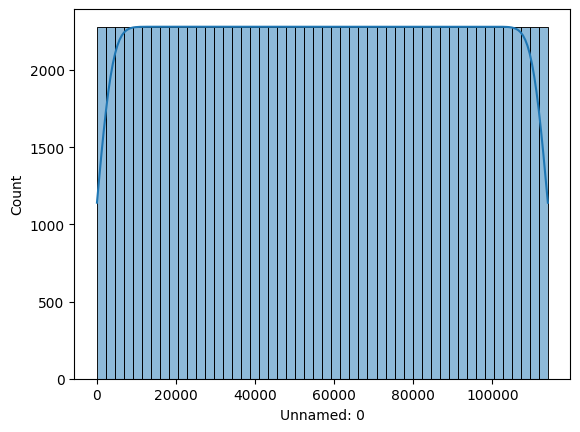

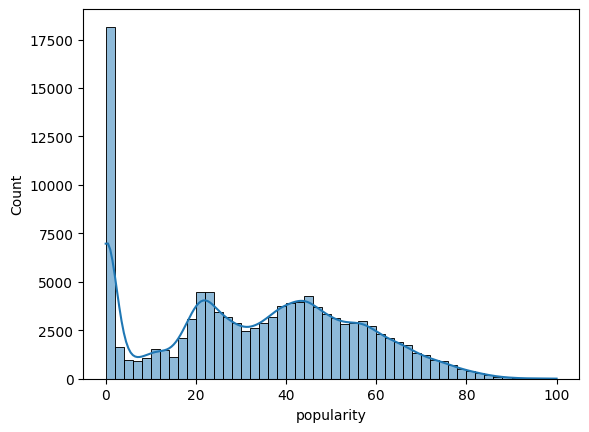

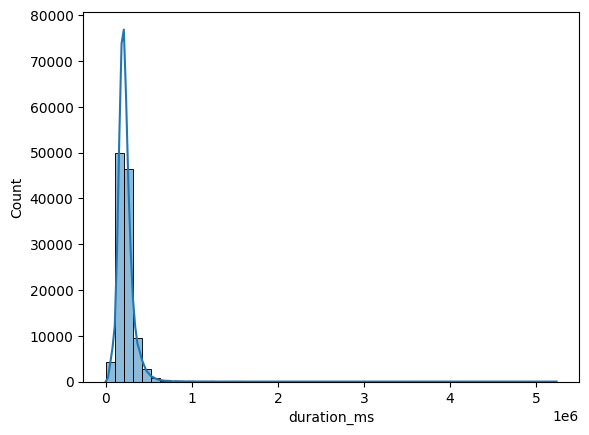

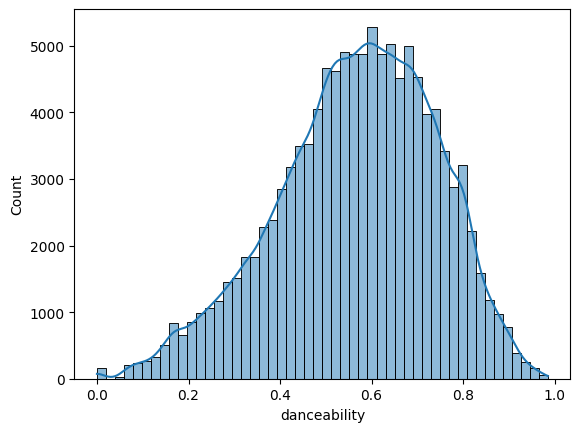

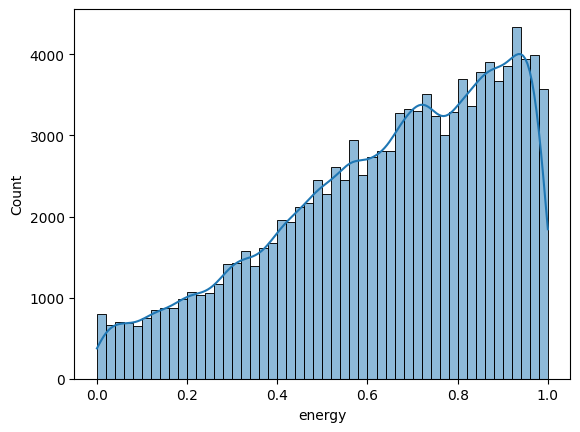

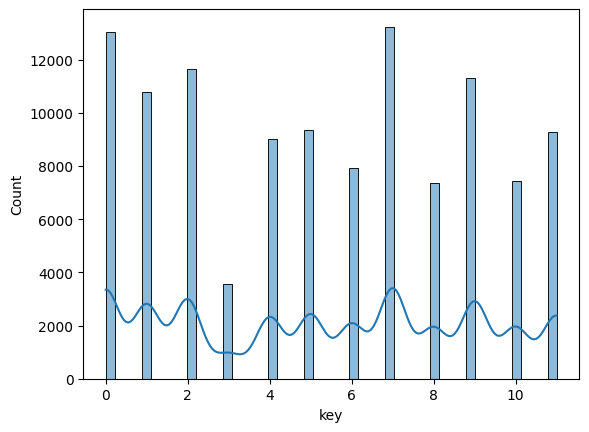

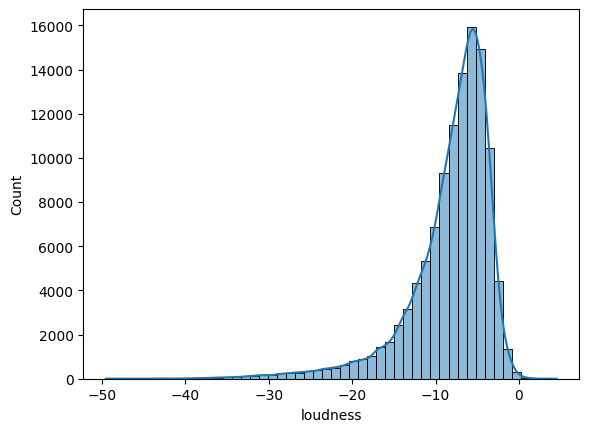

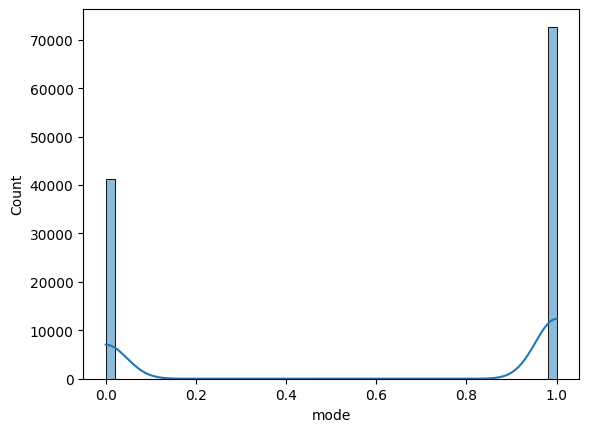

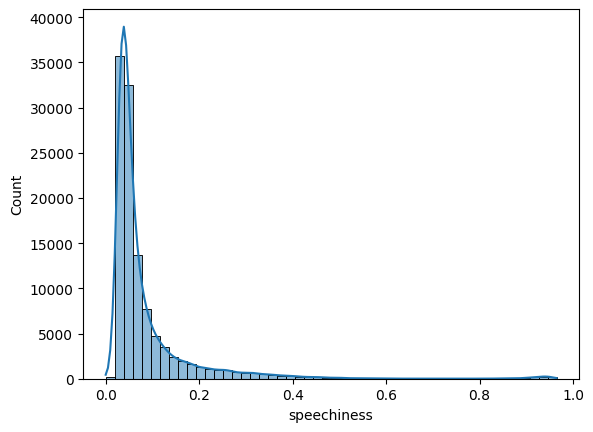

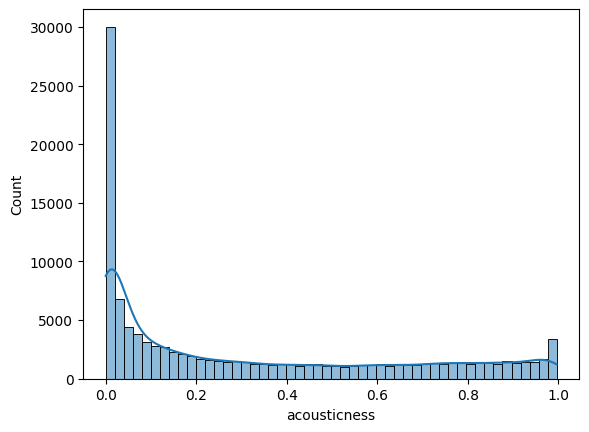

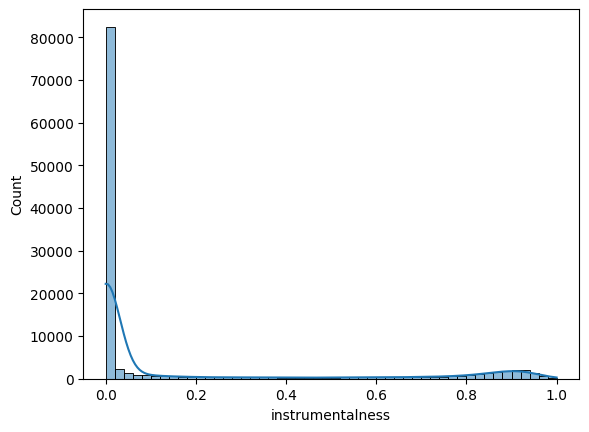

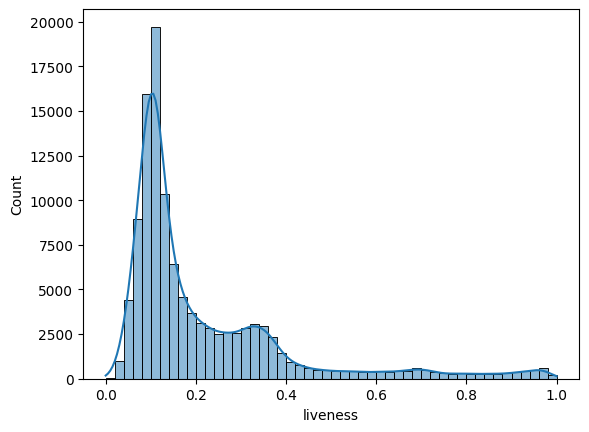

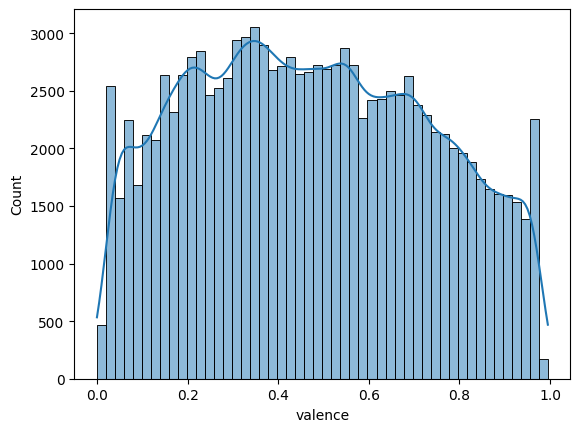

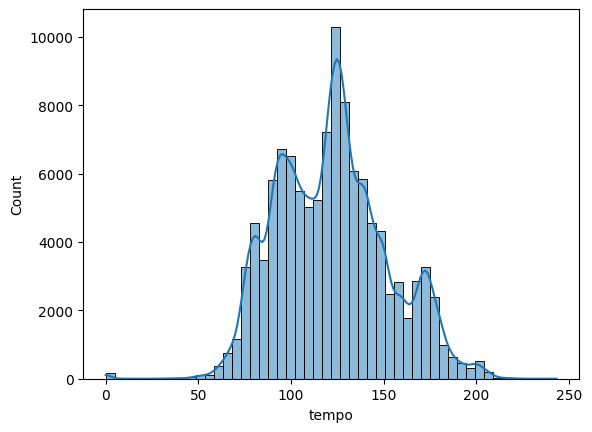

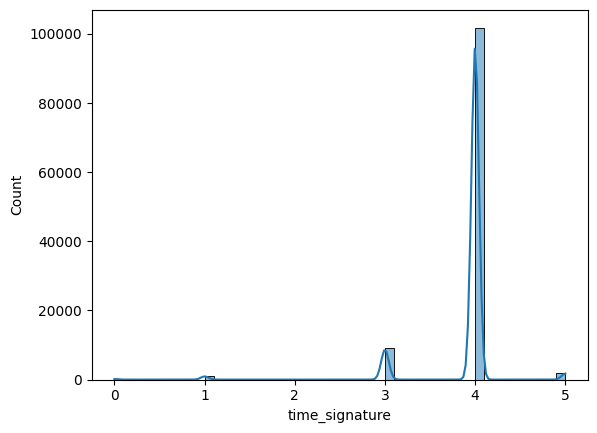

In [38]:
#Histogram with sns
#Though process: At first, I was going to make separate histogram code with sns but realized that would be extremely repetitive and inefficient, so I used some
#of my previous Java knowledge combined with the work I have previously done in this course to sort out categorical values and make histograms for them on a loop.

num_cols = tracks_df.select_dtypes(include=np.number).columns
for col in num_cols:
  sns.histplot(
      data=tracks_df,
      bins = 50,
      x=col,
      kde=True
  )
  plt.show()

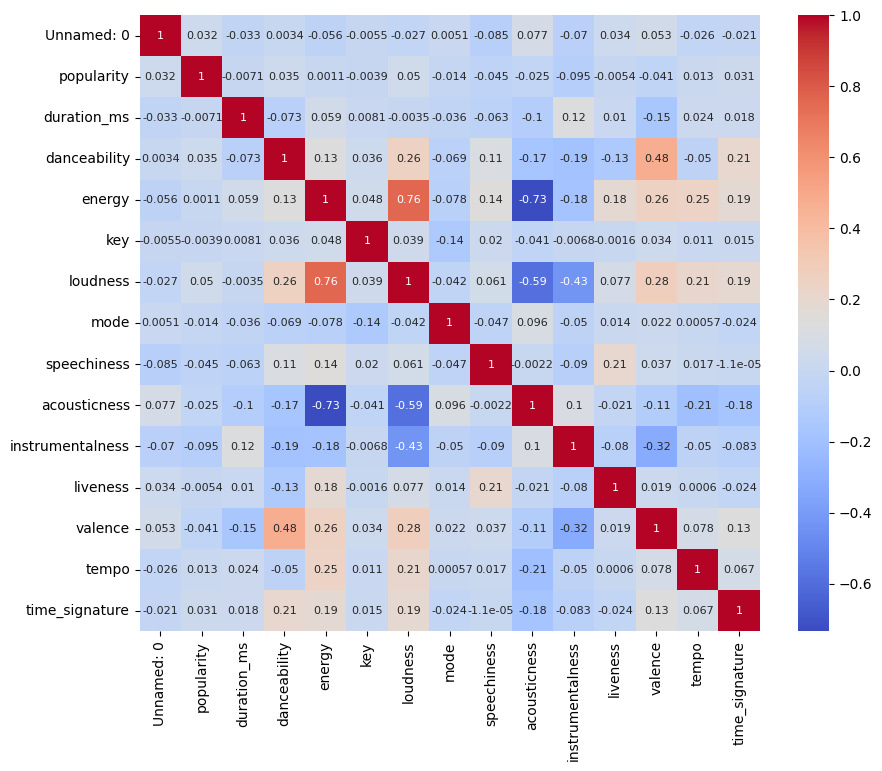

In [39]:
#heatmap with pandas
#Thought process: I used the same separation of categorical groups that I used to make the histograms, but I had problems with numbers overlapping, so I used Google
#to figure out how to make the box sizes larger so everything was easily comprehendible.

correlation_matrix = tracks_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws= {"fontsize": 8})
plt.show()

 **Question:** Explain your findings. Should there be any other variables added based on the entire dataset?*

"According to the heatmap, there is a strong positive correlation between energy and loudness, and a mild positive correlations between valence and danceability. There is a strong negative correlation between energy and acousticness and a mild negative correlation between loudness and acousticness. Based on the entire dataset, one potential variable to add could be the release year of the track. This could show more trends between what types of songs are popular in different years."

# **#2 Model Enhancement**

In [40]:
tracks = tracks_df[["acousticness","danceability","energy","instrumentalness","liveness","speechiness","valence"]]

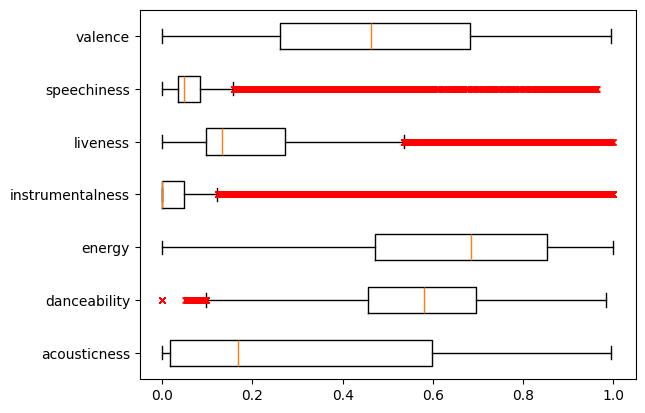

In [41]:
#Visualizes outliers
outliers = plt.boxplot(tracks,
                       orientation='horizontal',
                       tick_labels = ["acousticness","danceability","energy","instrumentalness","liveness","speechiness","valence"],
                       flierprops=dict(marker='x', markersize = '4', markeredgecolor='red', markerfacecolor = 'red'))
plt.show()

In [42]:
#removes outliers from all columns using the IQR method

columns = ["acousticness" ,"danceability","energy","instrumentalness","liveness","speechiness","valence"]

tracks_no_outliers = pd.DataFrame(index=tracks.index)

def outlier_remover(column):
  # calculates the quartiles of the column\n",
  q1 = tracks[column].quantile(0.25)
  q3 = tracks[column].quantile(0.75)
  iqr = q3 - q1
  print(f"Keep {column} larger than {q1 - 1.5 * iqr}, smaller than {q3 + 1.5 * iqr}")
  #concatenates the column, without outliers, into a new dataframe\n",
  global tracks_no_outliers
  tracks_no_outliers = pd.concat([tracks_no_outliers, tracks[(tracks[[column]] >= q1 - 1.5 * iqr) & (tracks[[column]] <= q3 + 1.5 * iqr)][column]], axis = 1)

for i in range(len(columns)):
  outlier_remover(columns[i])

tracks = tracks_no_outliers
tracks.head(10)

Keep acousticness larger than -0.8547499999999999, smaller than 1.46965
Keep danceability larger than 0.09750000000000009, smaller than 1.0534999999999999
Keep energy larger than -0.10099999999999998, smaller than 1.427
Keep instrumentalness larger than -0.07350000000000001, smaller than 0.12250000000000001
Keep liveness larger than -0.1645, smaller than 0.5355000000000001
Keep speechiness larger than -0.037000000000000005, smaller than 0.1574
Keep valence larger than -0.37450000000000006, smaller than 1.3175000000000001


,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence
0,0.0322,0.676,0.4610,0.000001,0.3580,0.1430,0.7150
1,0.9240,0.420,0.1660,0.000006,0.1010,0.0763,0.2670
2,0.2100,0.438,0.3590,0.000000,0.1170,0.0557,0.1200
3,0.9050,0.266,0.0596,0.000071,0.1320,0.0363,0.1430
4,0.4690,0.618,0.4430,0.000000,0.0829,0.0526,0.1670
5,0.2890,0.688,0.4810,0.000000,0.1890,0.1050,0.6660
6,0.8570,0.407,0.1470,0.000003,0.0913,0.0355,0.0765
7,0.5590,0.703,0.4440,0.000000,0.0973,0.0417,0.7120
8,0.2940,0.625,0.4140,0.000000,0.1510,0.0369,0.6690
9,0.4260,0.442,0.6320,0.004190,0.0735,0.0295,0.1960


In [43]:
#counts the number of NaNs now present in the dataset after removal of outliers

tracks.isnull().sum()

,0
acousticness,0
danceability,620
energy,0
instrumentalness,25246
liveness,8642
speechiness,13211
valence,0


In [44]:
#replace missing values with mean

tracks = tracks.fillna(tracks.mean(numeric_only=True))
tracks.isnull().sum()

,0
acousticness,0
danceability,0
energy,0
instrumentalness,0
liveness,0
speechiness,0
valence,0


**Question:** Explain your approach and how it helps in better model training.

Clustering methods like K-Means will cluster datapoints by distance. This means that outliers in values, which would result in a datapoint that is slightly far away from a group of points, would result in K-means and some other methods having their centroids skewed in the outlier's direction.

However, we still want to keep the rows in the dataset, as just removing rows with outliers would result in those songs being non-existent in the song-recommendation model. This could potentially under represent / be unfair to certain artists if they have a song that does not ever get recommended. This is why we chose to instead replace outliers with the mean of that column.

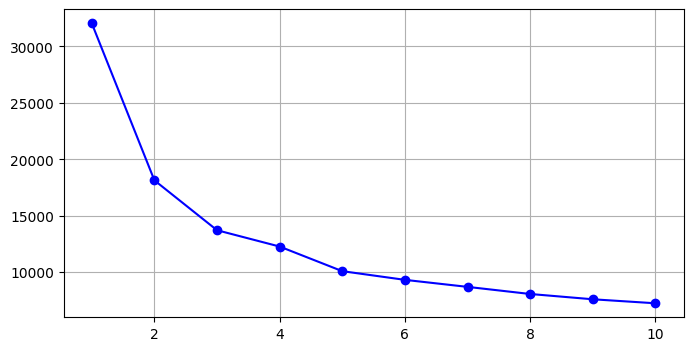

In [45]:
#elbow method with Kmeans
sse = []
k_range = range(1, 11)
for k in k_range:
  km = KMeans(n_clusters=k, random_state = 42)
  km.fit(tracks)
  sse.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, sse, 'bo-')
plt.grid(True)
plt.show()

In [46]:
#silhouette analysis method with KMeans
#Don't run, takes a long time
"""
from sklearn.metrics import silhouette_score, silhouette_samples

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = km.fit_predict(tracks)

    score = silhouette_score(tracks, labels)
    silhouette_scores.append(score)


# Plot average silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.grid(True)
plt.show()
"""

'\nfrom sklearn.metrics import silhouette_score, silhouette_samples\n\nk_values = range(2, 11)\nsilhouette_scores = []\n\nfor k in k_values:\n    km = KMeans(\n        n_clusters=k,\n        random_state=42,\n        n_init=10)\n\n    labels = km.fit_predict(tracks)\n\n    score = silhouette_score(tracks, labels)\n    silhouette_scores.append(score)\n\n\n# Plot average silhouette scores\nplt.figure(figsize=(8, 5))\nplt.plot(k_values, silhouette_scores, marker="o")\nplt.grid(True)\nplt.show()\n'

In [47]:
#attempt to find optimal amount of clusters using Gap Statistics
#Don't run, becomes an error because the dataset is too large

from gapstatistics.gapstatistics import GapStatistics

tracks_np = np.asarray(tracks)

gs = GapStatistics(distance_metric='minkowski')

optimum = gs.fit_predict(K=11, X=tracks_np)

print(f'Optimum: {optimum}')


ModuleNotFoundError: No module named 'gapstatistics'

**Question:** Discuss different techniques for finding the optimal number of clusters and explain your chosen method.

Three methods were attempted in order to find the optimal number of clusters: Elbow method, Silhouette analysis method, and Gap Statistics Method.

The chosen method moving forward is the elbow method, which suggests that the optimal number of clusters is 3-5.

This method was chosen as the other two methods tried struggled to handle the large dataset. The silhouette analysis method, which works by assigning each data point a number of how well it fits into its given cluster, was left to process for 5+ minutes and was still not finished. This need for excess time was unfavourable, and silhouette analysis was therefore not chosen.

The gap statistics method, on the other hand, had an error as it tried to compare the variation of points within a cluster to random unclustered data. Since the sample size of the 'tracks' dataset was 114000, the program needed to analyze a 114000 by 114000 array, which resulted in a runtime error.


In [ ]:
kmeans = KMeans(n_clusters = 3)

In [ ]:
kmeans.fit(tracks)

In [ ]:
KMeans(n_clusters = 5)

In [ ]:
tracks_df["type"] = kmeans.labels_

In [ ]:
tracks_df["type"]

In [ ]:
tracks_df.shape

In [ ]:
tracks_df.to_csv("result.csv", index=False)

In [ ]:
tracks = pd.read_csv("result.csv")

In [ ]:
tracks.head(13)

#**#3 User Interaction and Feedback**

In [ ]:
#the code already allows for multiple user inputs
ids = input('Enter comma-separated ids of your favorite songs\n> ').strip().split(',')

In [ ]:
try:
    ids = [int(id.strip()) for id in ids]
except ValueError:
    print("Invalid input. Please enter numeric IDs only.")
    ids = []

    print("\nEntered IDs:", ids)

In [ ]:
tracks = tracks.rename(columns={'Unnamed: 0': 'UID'})
favorites = tracks[tracks['UID'].isin(ids)]

In [ ]:
if favorites.empty:
  print("No matching songs with provided ID")
else:
  clusters = favorites['type'].value_counts()
  user_favorite_cluster = clusters.idxmax()

  print('\nFavorite cluster:', user_favorite_cluster, '\n')

In [ ]:
#the code already provides multiple reccomendations
suggestions = tracks[tracks['type'] == user_favorite_cluster]
suggestions.head()

print("Recommended Songs: ")
print(suggestions[['UID', 'track_name', 'artists', 'album_name']])

In [ ]:
#interactive prompt to collect feedback
#Thought process: I had to search up the format for how to make the answer work for different cases and different combinaitons of spaces; the rest was a simple if/else
feedback = input('Did you like these recommendations? (yes/no)\n> ').strip().lower()

if feedback == 'yes':
  print("I'm glad you liked them!")
else:
  print("Thanks for the feedback!")

# **#4 Innovation**

So far, our recommendations are just other songs in the same cluster that returned in whatever order they appear in the dataframe. They don't really express what kind of feeling those songs give off. This is why for our innovation, we plan to use an easier version of what's called the Russell's circumplex model of affect in order to map emotion onto two axes. Psychologists use this method to map emotions and we can do the same using our data. This allows us to filter down reccomendations based on mood.

In [48]:
# The mood classification is absed on valence and energy,
# which is positivity and intensity respectively.

happy = (tracks['valence'] >= 0.5) & (tracks['energy'] >= 0.5)
calm = (tracks['valence'] >= 0.5) & (tracks['energy'] < 0.5)
crashout = (tracks['valence'] < 0.5) & (tracks['energy'] >= 0.5)
sad = (tracks['valence'] < 0.5) & (tracks['energy'] < 0.5)

tracks['mood'] = np.select([happy, calm, crashout, sad],
                           ['Happy/Energetic', "Calm", "Angry", "Sad/Mellow"],
                           default='Unknown')
tracks['mood'].value_counts()

,count
mood,
Happy/Energetic,43405
Angry,38761
Sad/Mellow,23086
Calm,8748


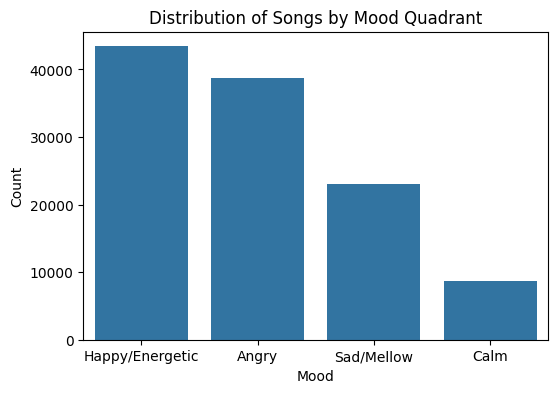

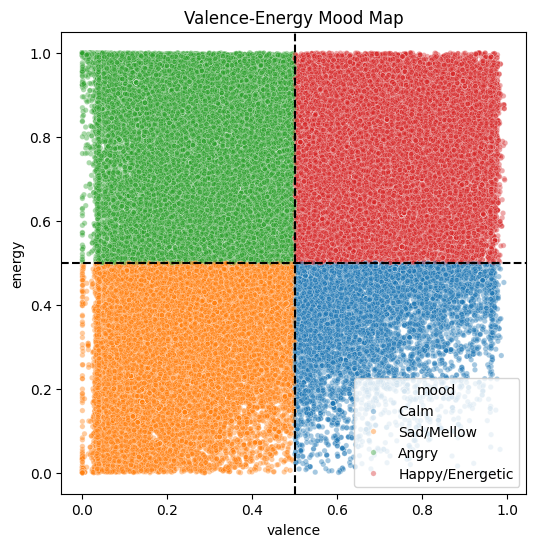

In [50]:
# In order to better understand this,
# we can visualize the mood distribution & valence-energy mood map

# Mood Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=tracks, x = 'mood', order = tracks['mood'].value_counts().index)
plt.title("Distribution of Songs by Mood Quadrant")
plt.xlabel("Mood")
plt.ylabel("Count")
plt.show()

# Valence-Energy Mood Map
plt.figure(figsize=(6,6))
sns.scatterplot(data=tracks, x = 'valence', y = 'energy', hue = 'mood', alpha = 0.4, s = 15)
plt.axvline(0.5, color = 'black', linestyle = '--')
plt.axhline(0.5, color = 'black', linestyle = '--')
plt.title('Valence-Energy Mood Map')
plt.show()

In [58]:
# Now we can develop the mood matched recommendations
# Thought Process: instead of returning every song in the user's favoirte cluster,
# we can narrow it down even further to songs that also share the ruling mood

def getMoodMatchedReccomendations(favorite_ids, top_n = 10):
    favs = tracks[tracks['UID'].isin(favorite_ids)]

    if (favs.empty):
      print("No matching songs found.")
      return None

    favCluster = favs['type'].value_counts().idxmmax()
    favMood = favs['mood'].value_counts().idxmax()
    candidates = tracks[(tracks['type'] == favCluster) & (tracks['mood'] == favMood)]

    # don't recommend songs the user already picked as favorites
    candidates = candidates[~candidates['UID'].isin(favorite_ids)]

    print(f"Favorite Cluster: {favCluster} | Dominant Mood: {favMood}")

    return candidates[['UID', 'track_name', 'artists', 'mood', 'type']].head(top_n)

In [ ]:
# Get mood matched recommendations for the user's favorite songs
moodRecommendations = getMoodMatchedRecommendations(ids, top_n = 10)
moodRecommendations

This is an innovation as it allows us to expand on our base model. The base model only offered what songs were similar with no way to differentiate how they feel. Mood tagging creates a layer that allows us to filter by mood so that recommendations are more targeted than just by using clusters alone.